In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../data/west_bengal_climate_final.nc"

ds = xr.open_dataset(DATA_PATH)

print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:             (time: 4018, latitude: 7, longitude: 5)
Coordinates:
  * time                (time) datetime64[ns] 32kB 2015-01-01 ... 2025-12-31
  * latitude            (latitude) float64 56B 21.5 22.5 23.5 ... 25.5 26.5 27.5
  * longitude           (longitude) float64 40B 85.5 86.5 87.5 88.5 89.5
Data variables:
    rainfall            (time, latitude, longitude) float64 1MB ...
    tmax                (time, latitude, longitude) float32 563kB ...
    tmin                (time, latitude, longitude) float32 563kB ...
    overlap_percentage  (latitude, longitude) float64 280B ...
    west_bengal_mask    (latitude, longitude) bool 35B ...
Attributes:
    title:                      VARUNA Climate Dataset
    description:                Daily IMD rainfall, maximum temperature, and ...
    region:                     West Bengal
    rainfall_source:            IMD 0.25 degree gridded rainfall
    temperature_source:         IMD 1 degree gridded temperatu

In [3]:
print("Dimensions:")
print(ds.dims)

print("\nVariables:")
print(list(ds.data_vars))

print("\nCoordinates:")
print(ds.coords)

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 4018, 'latitude': 7, 'longitude': 5})

Variables:
['rainfall', 'tmax', 'tmin', 'overlap_percentage', 'west_bengal_mask']

Coordinates:
Coordinates:
  * time       (time) datetime64[ns] 32kB 2015-01-01 2015-01-02 ... 2025-12-31
  * latitude   (latitude) float64 56B 21.5 22.5 23.5 24.5 25.5 26.5 27.5
  * longitude  (longitude) float64 40B 85.5 86.5 87.5 88.5 89.5


In [4]:
print("\nTime range:")
print(ds.time.values[0])
print(ds.time.values[-1])

print("\nNumber of days:")
print(len(ds.time))

print("\nLatitude:")
print(ds.latitude.values)

print("\nLongitude:")
print(ds.longitude.values)


Time range:
2015-01-01T00:00:00.000000000
2025-12-31T00:00:00.000000000

Number of days:
4018

Latitude:
[21.5 22.5 23.5 24.5 25.5 26.5 27.5]

Longitude:
[85.5 86.5 87.5 88.5 89.5]


In [5]:
tmax = ds["tmax"]
mask = ds["west_bengal_mask"].astype(bool)

print("Tmax shape:", tmax.shape)
print("Selected WB cells:", int(mask.sum()))

Tmax shape: (4018, 7, 5)
Selected WB cells: 14


In [7]:
tmax_with_doy = tmax.assign_coords(
    dayofyear=("time", tmax.time.dt.dayofyear.data)
)

In [8]:
tmax_climatology_mean = (
    tmax_with_doy
    .groupby("dayofyear")
    .mean(dim="time", skipna=True)
)

tmax_climatology_std = (
    tmax_with_doy
    .groupby("dayofyear")
    .std(dim="time", skipna=True)
)

In [10]:
print("Climatology mean:")
print(tmax_climatology_mean)

print("\nClimatology std:")
print(tmax_climatology_std)

Climatology mean:
<xarray.DataArray 'tmax' (dayofyear: 366, latitude: 7, longitude: 5)> Size: 51kB
array([[[      nan,       nan,       nan,       nan,       nan],
        [      nan, 24.563448, 24.079933, 24.19605 ,       nan],
        [23.796856, 24.194273, 23.948494, 23.983366,       nan],
        ...,
        [      nan,       nan, 23.435863, 23.54303 ,       nan],
        [      nan,       nan, 20.219208,       nan, 21.87846 ],
        [      nan,       nan,       nan, 20.662838,       nan]],

       [[      nan,       nan,       nan,       nan,       nan],
        [      nan, 24.50343 , 24.186438, 24.100164,       nan],
        [23.652613, 24.217705, 24.162262, 24.374092,       nan],
        ...,
        [      nan,       nan, 23.389044, 23.80819 ,       nan],
        [      nan,       nan, 20.72438 ,       nan, 21.946861],
        [      nan,       nan,       nan, 20.943926,       nan]],

       [[      nan,       nan,       nan,       nan,       nan],
        [      nan, 24.479

In [11]:
tmax_anomaly = (
    tmax_with_doy.groupby("dayofyear")
    - tmax_climatology_mean
)

In [12]:
tmax_zscore = (
    tmax_anomaly.groupby("dayofyear")
    / tmax_climatology_std
)

tmax_zscore = tmax_zscore.where(
    tmax_climatology_std > 0
)

In [13]:
HOT_THRESHOLD = 2.0
COLD_THRESHOLD = -2.0

In [14]:
hot_anomaly = tmax_zscore >= HOT_THRESHOLD

cold_anomaly = tmax_zscore <= COLD_THRESHOLD

In [15]:
temperature_anomaly = xr.where(
    hot_anomaly,
    1,
    xr.where(
        cold_anomaly,
        -1,
        0
    )
)

In [16]:
tmax_anomaly_wb = tmax_anomaly.where(mask)

tmax_zscore_wb = tmax_zscore.where(mask)

temperature_anomaly_wb = temperature_anomaly.where(mask)

In [17]:
temperature_status = xr.where(
    hot_anomaly,
    "HOT_ANOMALY",
    xr.where(
        cold_anomaly,
        "COLD_ANOMALY",
        "NORMAL"
    )
)

temperature_status_wb = temperature_status.where(mask)

In [18]:
anomaly_ds = xr.Dataset({
    "tmax": tmax.where(mask),
    "tmax_anomaly": tmax_anomaly_wb,
    "tmax_zscore": tmax_zscore_wb,
    "temperature_anomaly": temperature_anomaly_wb,
    "temperature_status": temperature_status_wb
})

print(anomaly_ds)

<xarray.Dataset> Size: 1GB
Dimensions:              (time: 4018, latitude: 7, longitude: 5, dayofyear: 366)
Coordinates:
  * time                 (time) datetime64[ns] 32kB 2015-01-01 ... 2025-12-31
  * latitude             (latitude) float64 56B 21.5 22.5 23.5 ... 26.5 27.5
  * longitude            (longitude) float64 40B 85.5 86.5 87.5 88.5 89.5
  * dayofyear            (dayofyear) int64 3kB 1 2 3 4 5 ... 362 363 364 365 366
Data variables:
    tmax                 (time, latitude, longitude) float32 563kB nan ... nan
    tmax_anomaly         (time, latitude, longitude) float32 563kB nan ... nan
    tmax_zscore          (time, latitude, longitude, dayofyear) float32 206MB ...
    temperature_anomaly  (time, latitude, longitude, dayofyear) float64 412MB ...
    temperature_status   (time, latitude, longitude, dayofyear) object 412MB ...


In [19]:
anomaly_df = anomaly_ds.to_dataframe().reset_index()

anomaly_df = anomaly_df[
    anomaly_df["tmax"].notna()
].copy()

print(anomaly_df.head())
print("\nShape:", anomaly_df.shape)

           time  latitude  longitude  dayofyear       tmax  tmax_anomaly  \
2196 2015-01-01      22.5       86.5          1  23.892088      -0.67136   
2197 2015-01-01      22.5       86.5          2  23.892088      -0.67136   
2198 2015-01-01      22.5       86.5          3  23.892088      -0.67136   
2199 2015-01-01      22.5       86.5          4  23.892088      -0.67136   
2200 2015-01-01      22.5       86.5          5  23.892088      -0.67136   

      tmax_zscore  temperature_anomaly temperature_status  
2196    -0.678487                  0.0             NORMAL  
2197    -0.678487                  0.0             NORMAL  
2198    -0.678487                  0.0             NORMAL  
2199    -0.678487                  0.0             NORMAL  
2200    -0.678487                  0.0             NORMAL  

Shape: (20588232, 9)


In [22]:
normal_tmax = tmax_climatology_mean.sel(
    dayofyear=tmax_with_doy["dayofyear"]
)

# Make sure the time coordinate matches the original dataset
normal_tmax = normal_tmax.assign_coords(
    time=ds.time
)

normal_df = (
    normal_tmax
    .where(mask)
    .to_dataframe(name="normal_tmax")
    .reset_index()
)

normal_df = normal_df[
    normal_df["normal_tmax"].notna()
].copy()

print(normal_df.head())
print("\nShape:", normal_df.shape)

         time  latitude  longitude  dayofyear  normal_tmax
6  2015-01-01      22.5       86.5          1    24.563448
7  2015-01-01      22.5       87.5          1    24.079933
8  2015-01-01      22.5       88.5          1    24.196051
10 2015-01-01      23.5       85.5          1    23.796856
11 2015-01-01      23.5       86.5          1    24.194273

Shape: (56252, 5)


In [23]:
anomaly_df = anomaly_df.merge(
    normal_df,
    on=["time", "latitude", "longitude"],
    how="left"
)

In [24]:
anomaly_df["anomaly_celsius"] = (
    anomaly_df["tmax"]
    - anomaly_df["normal_tmax"]
)

In [25]:
anomaly_df = anomaly_df.rename(
    columns={
        "time": "date",
        "temperature_anomaly": "anomaly_class"
    }
)

anomaly_df["date"] = pd.to_datetime(
    anomaly_df["date"]
)

anomaly_df = anomaly_df.sort_values(
    ["date", "latitude", "longitude"]
).reset_index(drop=True)

print(anomaly_df.head(10))

        date  latitude  longitude  dayofyear_x       tmax  tmax_anomaly  \
0 2015-01-01      22.5       86.5            1  23.892088      -0.67136   
1 2015-01-01      22.5       86.5            2  23.892088      -0.67136   
2 2015-01-01      22.5       86.5            3  23.892088      -0.67136   
3 2015-01-01      22.5       86.5            4  23.892088      -0.67136   
4 2015-01-01      22.5       86.5            5  23.892088      -0.67136   
5 2015-01-01      22.5       86.5            6  23.892088      -0.67136   
6 2015-01-01      22.5       86.5            7  23.892088      -0.67136   
7 2015-01-01      22.5       86.5            8  23.892088      -0.67136   
8 2015-01-01      22.5       86.5            9  23.892088      -0.67136   
9 2015-01-01      22.5       86.5           10  23.892088      -0.67136   

   tmax_zscore  anomaly_class temperature_status  dayofyear_y  normal_tmax  \
0    -0.678487            0.0             NORMAL            1    24.563448   
1    -0.678487    

In [26]:
print(
    anomaly_df["temperature_status"]
    .value_counts()
)

temperature_status
NORMAL          19721544
COLD_ANOMALY      607194
HOT_ANOMALY       259494
Name: count, dtype: int64


In [27]:
print(
    anomaly_df["temperature_status"]
    .value_counts(normalize=True).mul(100).round(2)
)

temperature_status
NORMAL          95.79
COLD_ANOMALY     2.95
HOT_ANOMALY      1.26
Name: proportion, dtype: float64


In [29]:
strongest_hot = (
    anomaly_df
    .dropna(subset=["tmax_zscore"])
    .sort_values("tmax_zscore", ascending=False)
    .head(20)
)

print(
    strongest_hot[
        [
            "date",
            "latitude",
            "longitude",
            "tmax",
            "normal_tmax",
            "anomaly_celsius",
            "tmax_zscore",
            "temperature_status"
        ]
    ].to_string(index=False)
)

      date  latitude  longitude      tmax  normal_tmax  anomaly_celsius  tmax_zscore temperature_status
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335     2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335     2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335     2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335     2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335     2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335     2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335     2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335     2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          

In [30]:
print(anomaly_df.columns.tolist())

['date', 'latitude', 'longitude', 'dayofyear_x', 'tmax', 'tmax_anomaly', 'tmax_zscore', 'anomaly_class', 'temperature_status', 'dayofyear_y', 'normal_tmax', 'anomaly_celsius']


In [31]:
# Make column names consistent
anomaly_df = anomaly_df.rename(
    columns={
        "time": "date",
        "tmax_anomaly": "anomaly_celsius",
        "tmax_zscore": "zscore",
        "temperature_anomaly": "anomaly_class"
    }
)

# Find strongest hot anomalies
strongest_hot = (
    anomaly_df
    .dropna(subset=["zscore"])
    .sort_values("zscore", ascending=False)
    .head(20)
)

print(
    strongest_hot[
        [
            "date",
            "latitude",
            "longitude",
            "tmax",
            "normal_tmax",
            "anomaly_celsius",
            "zscore",
            "temperature_status"
        ]
    ].to_string(index=False)
)

      date  latitude  longitude      tmax  normal_tmax  anomaly_celsius  anomaly_celsius   zscore temperature_status
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335          5.30335 2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335          5.30335 2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335          5.30335 2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335          5.30335 2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335          5.30335 2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335          5.30335 2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          5.30335          5.30335 2.881725        HOT_ANOMALY
2016-02-19      22.5       87.5 35.810322    30.506971          

In [32]:
strongest_cold = (
    anomaly_df
    .dropna(subset=["zscore"])
    .sort_values("zscore", ascending=True)
    .head(20)
)

print(
    strongest_cold[
        [
            "date",
            "latitude",
            "longitude",
            "tmax",
            "normal_tmax",
            "anomaly_celsius",
            "zscore",
            "temperature_status"
        ]
    ].to_string(index=False)
)

      date  latitude  longitude      tmax  normal_tmax  anomaly_celsius  anomaly_celsius    zscore temperature_status
2019-11-09      22.5       86.5 23.810986    29.564531        -5.753546        -5.753546 -3.067937       COLD_ANOMALY
2019-11-09      22.5       86.5 23.810986    29.564531        -5.753546        -5.753546 -3.067937       COLD_ANOMALY
2019-11-09      22.5       86.5 23.810986    29.564531        -5.753546        -5.753546 -3.067937       COLD_ANOMALY
2019-11-09      22.5       86.5 23.810986    29.564531        -5.753546        -5.753546 -3.067937       COLD_ANOMALY
2019-11-09      22.5       86.5 23.810986    29.564531        -5.753546        -5.753546 -3.067937       COLD_ANOMALY
2019-11-09      22.5       86.5 23.810986    29.564531        -5.753546        -5.753546 -3.067937       COLD_ANOMALY
2019-11-09      22.5       86.5 23.810986    29.564531        -5.753546        -5.753546 -3.067937       COLD_ANOMALY
2019-11-09      22.5       86.5 23.810986    29.564531  

In [34]:
ANOMALY_DIR = "../results/anomaly"

os.makedirs(
    ANOMALY_DIR,
    exist_ok=True
)

In [35]:
anomaly_df.to_csv(
    "../results/anomaly/tmax_anomaly_records.csv",
    index=False
)

In [36]:
strongest_hot.to_csv(
    "../results/anomaly/strongest_hot_anomalies.csv",
    index=False
)

strongest_cold.to_csv(
    "../results/anomaly/strongest_cold_anomalies.csv",
    index=False
)

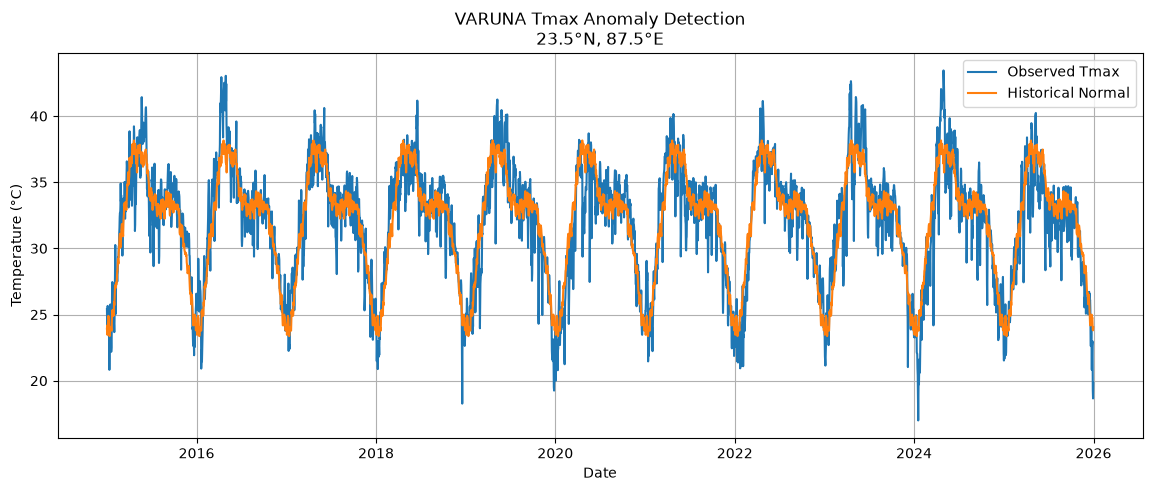

In [37]:
LAT = 23.5
LON = 87.5

cell = anomaly_df[
    (anomaly_df["latitude"] == LAT) &
    (anomaly_df["longitude"] == LON)
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    cell["date"],
    cell["tmax"],
    label="Observed Tmax"
)

plt.plot(
    cell["date"],
    cell["normal_tmax"],
    label="Historical Normal"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title(
    f"VARUNA Tmax Anomaly Detection\n"
    f"{LAT}°N, {LON}°E"
)

plt.legend()
plt.grid(True)
plt.show()

In [39]:
import os
import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# 1. CALCULATE HISTORICAL CLIMATOLOGY
# ============================================================

def calculate_climatology(tmax):
    """
    Calculate day-of-year climatological mean and standard
    deviation for Tmax at every grid cell.
    """

    # Extract day-of-year values
    dayofyear = tmax.time.dt.dayofyear.data

    # Add day-of-year as a coordinate
    tmax_with_doy = tmax.assign_coords(
        dayofyear=("time", dayofyear)
    )

    # Historical mean for each day-of-year
    climatology_mean = (
        tmax_with_doy
        .groupby("dayofyear")
        .mean(dim="time", skipna=True)
    )

    # Historical standard deviation for each day-of-year
    climatology_std = (
        tmax_with_doy
        .groupby("dayofyear")
        .std(dim="time", skipna=True)
    )

    return (
        tmax_with_doy,
        climatology_mean,
        climatology_std
    )


# ============================================================
# 2. CALCULATE TEMPERATURE ANOMALY AND Z-SCORE
# ============================================================

def calculate_temperature_anomaly(
    tmax,
    tmax_with_doy,
    climatology_mean,
    climatology_std
):
    """
    Calculate:
        Normal Tmax
        Temperature anomaly
        Z-score
    """

    # Create a DataArray containing the day-of-year for
    # every actual observation date
    doy_indexer = xr.DataArray(
        tmax_with_doy["dayofyear"].data,
        dims="time"
    )

    # Historical normal Tmax corresponding to each date
    normal_tmax = climatology_mean.sel(
        dayofyear=doy_indexer
    )

    # Historical standard deviation corresponding to each date
    normal_std = climatology_std.sel(
        dayofyear=doy_indexer
    )

    # Restore the original time coordinate
    normal_tmax = normal_tmax.assign_coords(
        time=tmax.time
    )

    normal_std = normal_std.assign_coords(
        time=tmax.time
    )

    # Temperature anomaly in Celsius
    temperature_anomaly = (
        tmax - normal_tmax
    )

    # Z-score
    zscore = (
        temperature_anomaly / normal_std
    )

    # Avoid division by zero
    zscore = zscore.where(
        normal_std > 0
    )

    return (
        normal_tmax,
        temperature_anomaly,
        zscore
    )


# ============================================================
# 3. CLASSIFY TEMPERATURE ANOMALIES
# ============================================================

def classify_temperature_anomaly(
    zscore,
    hot_threshold=2.0,
    cold_threshold=-2.0
):
    """
    Classification:

        +1 = HOT ANOMALY
         0 = NORMAL
        -1 = COLD ANOMALY
    """

    hot_anomaly = (
        zscore >= hot_threshold
    )

    cold_anomaly = (
        zscore <= cold_threshold
    )

    anomaly_class = xr.where(
        hot_anomaly,
        1,
        xr.where(
            cold_anomaly,
            -1,
            0
        )
    )

    temperature_status = xr.where(
        hot_anomaly,
        "HOT_ANOMALY",
        xr.where(
            cold_anomaly,
            "COLD_ANOMALY",
            "NORMAL"
        )
    )

    return (
        anomaly_class,
        temperature_status,
        hot_anomaly,
        cold_anomaly
    )


# ============================================================
# 4. GENERATE ANOMALY TABLE
# ============================================================

def generate_anomaly_table(
    tmax,
    normal_tmax,
    temperature_anomaly,
    zscore,
    anomaly_class,
    temperature_status,
    mask
):
    """
    Generate a Pandas DataFrame containing all
    anomaly-detection results.
    """

    # Create Xarray dataset
    anomaly_ds = xr.Dataset({

        "tmax": tmax,

        "normal_tmax": normal_tmax,

        "anomaly_celsius": temperature_anomaly,

        "zscore": zscore,

        "anomaly_class": anomaly_class,

        "temperature_status": temperature_status
    })

    # Apply West Bengal mask
    anomaly_ds = anomaly_ds.where(mask)

    # Convert Xarray → Pandas
    anomaly_df = (
        anomaly_ds
        .to_dataframe()
        .reset_index()
    )

    # Remove grid cells outside selected West Bengal area
    anomaly_df = anomaly_df[
        anomaly_df["tmax"].notna()
    ].copy()

    # Convert date
    anomaly_df["date"] = pd.to_datetime(
        anomaly_df["time"]
    )

    # Remove duplicate time column
    anomaly_df = anomaly_df.drop(
        columns=["time"]
    )

    # Sort
    anomaly_df = anomaly_df.sort_values(
        [
            "date",
            "latitude",
            "longitude"
        ]
    ).reset_index(drop=True)

    return anomaly_df


# ============================================================
# 5. RUN THE COMPLETE ANOMALY DETECTION PIPELINE
# ============================================================

# Tmax from your VARUNA dataset
tmax = ds["tmax"]

# West Bengal geographic mask
mask = ds["west_bengal_mask"].astype(bool)


# ------------------------------------------------------------
# Step A: Historical climatology
# ------------------------------------------------------------

(
    tmax_with_doy,
    tmax_climatology_mean,
    tmax_climatology_std
) = calculate_climatology(tmax)


# ------------------------------------------------------------
# Step B: Temperature anomaly + Z-score
# ------------------------------------------------------------

(
    normal_tmax,
    temperature_anomaly,
    zscore
) = calculate_temperature_anomaly(
    tmax,
    tmax_with_doy,
    tmax_climatology_mean,
    tmax_climatology_std
)


# ------------------------------------------------------------
# Step C: Classification
# ------------------------------------------------------------

(
    anomaly_class,
    temperature_status,
    hot_anomaly,
    cold_anomaly
) = classify_temperature_anomaly(
    zscore,
    hot_threshold=2.0,
    cold_threshold=-2.0
)


# ------------------------------------------------------------
# Step D: Generate final table
# ------------------------------------------------------------

anomaly_df = generate_anomaly_table(
    tmax=tmax,
    normal_tmax=normal_tmax,
    temperature_anomaly=temperature_anomaly,
    zscore=zscore,
    anomaly_class=anomaly_class,
    temperature_status=temperature_status,
    mask=mask
)


# ============================================================
# 6. DISPLAY RESULTS
# ============================================================

print("=" * 60)
print("VARUNA TEMPERATURE ANOMALY DETECTION")
print("=" * 60)

print("\nDataset shape:")
print(tmax.shape)

print("\nSelected West Bengal grid cells:")
print(int(mask.sum()))

print("\nAnomaly records:")
print(len(anomaly_df))

print("\nColumns:")
print(anomaly_df.columns.tolist())

print("\nFirst 10 records:")
print(
    anomaly_df.head(10).to_string(
        index=False
    )
)


# ============================================================
# 7. ANOMALY COUNTS
# ============================================================

print("\n" + "=" * 60)
print("ANOMALY COUNTS")
print("=" * 60)

status_counts = (
    anomaly_df["temperature_status"]
    .value_counts()
)

print(status_counts)


# ============================================================
# 8. ANOMALY PERCENTAGES
# ============================================================

print("\n" + "=" * 60)
print("ANOMALY PERCENTAGES")
print("=" * 60)

status_percentages = (
    anomaly_df["temperature_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(status_percentages)


# ============================================================
# 9. STRONGEST HOT ANOMALIES
# ============================================================

strongest_hot = (
    anomaly_df
    .dropna(subset=["zscore"])
    .sort_values(
        "zscore",
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 60)
print("TOP 20 HOT ANOMALIES")
print("=" * 60)

print(
    strongest_hot[
        [
            "date",
            "latitude",
            "longitude",
            "tmax",
            "normal_tmax",
            "anomaly_celsius",
            "zscore",
            "temperature_status"
        ]
    ].to_string(index=False)
)


# ============================================================
# 10. STRONGEST COLD ANOMALIES
# ============================================================

strongest_cold = (
    anomaly_df
    .dropna(subset=["zscore"])
    .sort_values(
        "zscore",
        ascending=True
    )
    .head(20)
)

print("\n" + "=" * 60)
print("TOP 20 COLD ANOMALIES")
print("=" * 60)

print(
    strongest_cold[
        [
            "date",
            "latitude",
            "longitude",
            "tmax",
            "normal_tmax",
            "anomaly_celsius",
            "zscore",
            "temperature_status"
        ]
    ].to_string(index=False)
)

VARUNA TEMPERATURE ANOMALY DETECTION

Dataset shape:
(4018, 7, 5)

Selected West Bengal grid cells:
14

Anomaly records:
56252

Columns:
['latitude', 'longitude', 'tmax', 'normal_tmax', 'anomaly_celsius', 'zscore', 'anomaly_class', 'temperature_status', 'dayofyear', 'date']

First 10 records:
 latitude  longitude      tmax  normal_tmax  anomaly_celsius    zscore  anomaly_class temperature_status  dayofyear       date
     22.5       86.5 23.892088    24.563448        -0.671360 -0.678487            0.0             NORMAL          1 2015-01-01
     22.5       87.5 23.817703    24.079933        -0.262230 -0.223111            0.0             NORMAL          1 2015-01-01
     22.5       88.5 24.163929    24.196051        -0.032122 -0.029432            0.0             NORMAL          1 2015-01-01
     23.5       85.5 25.314230    23.796856         1.517374  0.851994            0.0             NORMAL          1 2015-01-01
     23.5       86.5 24.875227    24.194273         0.680954  0.621900 

In [40]:
# Create anomaly results folder
ANOMALY_DIR = "../results/anomaly"

os.makedirs(
    ANOMALY_DIR,
    exist_ok=True
)

# Save all anomaly records
anomaly_df.to_csv(
    os.path.join(
        ANOMALY_DIR,
        "tmax_anomaly_records.csv"
    ),
    index=False
)

# Save strongest hot anomalies
strongest_hot.to_csv(
    os.path.join(
        ANOMALY_DIR,
        "strongest_hot_anomalies.csv"
    ),
    index=False
)

# Save strongest cold anomalies
strongest_cold.to_csv(
    os.path.join(
        ANOMALY_DIR,
        "strongest_cold_anomalies.csv"
    ),
    index=False
)

print("Anomaly results saved successfully.")

Anomaly results saved successfully.
